In [1]:
import numpy as np
from scipy.optimize import leastsq, curve_fit

from matplotlib import pyplot as plt
from scipy import stats
import pandas as pd
from natsort import natsorted

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [63]:
mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'purple', 'teal']
mass_spec_mutant_colors = ['red', 'deepskyblue', 'fuchsia', 'turquoise']
mutant_markers = ["o", "v", "s", "D"]

In [3]:
def load_uv_data(filename):
    d = np.genfromtxt(filename, skip_header=3, skip_footer=2500)
    d = np.hstack( [ d[:,0][:,None], d[:,1::2] ] )
    return d

In [ ]:
FIXED_SIGMA = 0.013

def double_gaussian(x, params):
    
    (c1, mu1, sigma1, c2, mu2, sigma2) = params

    if FIXED_SIGMA:
        sigma1 = sigma2 = 0.013
    
    res =   c1 * np.exp( - (x - mu1)**2.0 / (2.0 * sigma1**2.0) ) \
          + c2 * np.exp( - (x - mu2)**2.0 / (2.0 * sigma2**2.0) )
    return res


def fit_double_gaussian(x, y):
    
    # c1, mu1, sigma1, c2, mu2, sigma2
    x0 = [1.0, 0.428, 0.01, 
          1.0, 0.474, 0.01] 
    
    def dgf(params):
        fit = double_gaussian(x, params)
        return (fit - y)
    
    fit = leastsq(dgf, x0)

    return fit


def ratio_area_under_gaussians(params):
    """ returns the fraction of chains in monomeric form, R """
    (c1, mu1, sigma1, c2, mu2, sigma2) = params
    coeff = np.sqrt(2.0 * np.pi)
    A1 = coeff * np.abs(c1) * sigma1  # dimer peak
    A2 = coeff * np.abs(c2) * sigma2  # monomer peak
    return A2 / (A1 + A2)

In [5]:
all_data = {}

for mutant in mutants:
    fn = './S75inc_300-10/{}_sec.csv'.format(mutant)
    d = load_uv_data(fn)
        
    all_data[mutant] = d

In [6]:
# peak positions
low_cv_cutoff = 0.35
hgh_cv_cutoff = 0.55

## calibration curve to turn UV mAU to protein concentration

We'll use the wt Mpro curves to do this by fitting a line to the AUC from the chromatogram to the nominal injected concentration.

In [7]:
wt_data = all_data['wt']

nominal_concentrations = [0.8, 25.0, 12.5, 3.1, 6.2, 1.6]
#nominal_concentrations = np.arange(6)
AUCs = []

for i in range(1, len(nominal_concentrations)+1):
    
    CV = wt_data[:,0] / 24.0
    
    start = np.argmin(np.abs(CV - low_cv_cutoff))
    end   = np.argmin(np.abs(CV - hgh_cv_cutoff))
    
    UV = (wt_data[:,i] - np.median(wt_data[:,i]))
    auc = UV[start:end].sum()
    AUCs.append(auc)
    
AUCs = np.array(AUCs)

In [8]:
m, _, _, _ = np.linalg.lstsq(AUCs[:,np.newaxis], nominal_concentrations)
print(m)

[0.00412462]


/var/folders/s9/bht_sc9n7ys6m0q3h_3htntc0000gn/T/ipykernel_19182/2341755166.py:1: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  m, _, _, _ = np.linalg.lstsq(AUCs[:,np.newaxis], nominal_concentrations)


In [9]:
def auc_to_concentration(auc):
    m = 0.00412462
    return m * auc

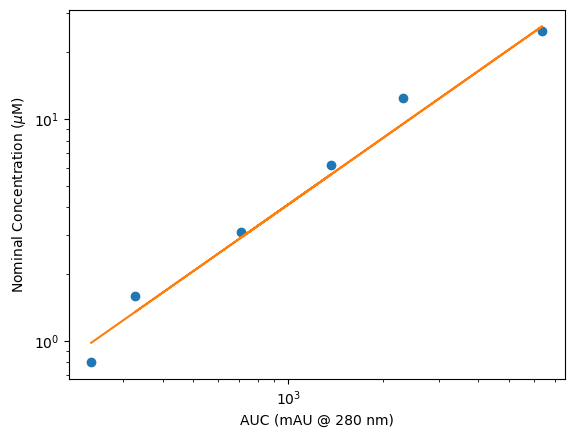

In [10]:
plt.figure()
plt.plot(AUCs, nominal_concentrations, 'o')
plt.plot(AUCs, auc_to_concentration(AUCs))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('AUC (mAU @ 280 nm)')
plt.ylabel('Nominal Concentration ($\mu$M)')
plt.show()

## Load native mass spec data

In [19]:
ms_data = pd.read_csv("../native_ms/native_mass_spec_monomer-dimer_fractions.csv")
ms_data

,replicate,mutant,[P] (µM),Monomer Mass,Dimer Mass,monomer intensity,dimer intensity,R (frac mono),Unnamed: 8
0,1,N214A,2,33740,67510,9.981297e+06,2.609416e+06,0.793,NaN
1,2,N214A,2,33740,67510,1.022195e+07,2.850770e+06,0.782,NaN
2,3,N214A,2,33740,67510,6.163272e+06,1.185548e+06,0.839,NaN
3,1,WT,2,33790,67600,1.615271e+06,1.735417e+06,0.482,NaN
4,2,WT,2,33790,67600,6.302550e+05,1.355899e+06,0.317,NaN
5,3,WT,2,33790,67600,1.162177e+06,9.949662e+05,0.539,NaN
6,1,Q256A,2,33740,67490,7.763344e+05,8.278356e+05,0.484,NaN
7,2,Q256A,2,33740,67490,1.241304e+06,1.032203e+06,0.546,NaN
8,3,Q256A,2,33740,67490,1.345201e+06,1.107960e+06,0.548,NaN
9,1,S284A,2,33780,67570,6.568312e+05,9.483629e+05,0.409,NaN


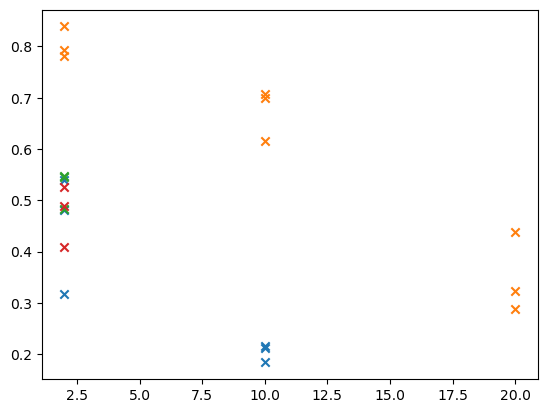

In [62]:
plt.figure()
ax = plt.subplot(111)

for im,m in enumerate(mutants):

    mutant_specific_ms_data = ms_data[ms_data["mutant"] == m.upper()]
    ms_concentrations = mutant_specific_ms_data["[P] (µM)"]
    ms_ratios = mutant_specific_ms_data["R (frac mono)"]

    ax.scatter(
        ms_concentrations,
        ms_ratios,
        marker="x"
    )


plt.show()

## analyze the ratio of monomer to dimer as a function of concentration for each mutant

NB we treat the N214A mutant differently, assuming it is under "fast exchange". All others are treated in the "slow exchange" approximation.

## physical model

2M <-> D

$$
\begin{align}
K &= M^2 / D \\
P &= 2D + M \ \ \text{(total protein)} \\
R &= M / P
\end{align}
$$

solving the quardratic equation for M gives

$$
R = \frac{ \sqrt{8K^{-1}P + 1} - 1 }{ 4K^{-1}P }
$$

Under slow exchange, R is given by the ratio of the monomer peak to the total AUC.

Under fast exchange, R is the average elution volume...

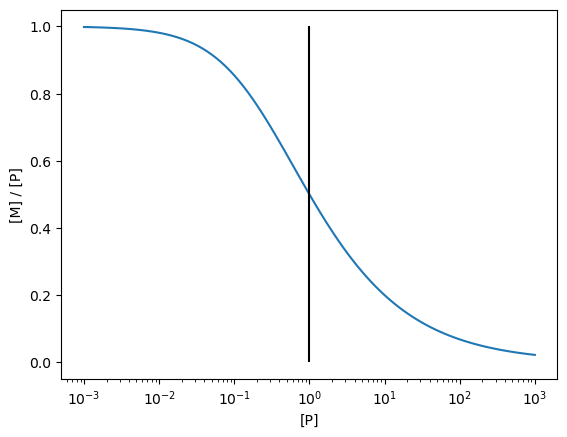

In [11]:
def r_p(p, K):
    return (np.sqrt(8*p/K + 1) - 1) / (4*p/K)

K_test = 1.0
x = np.logspace(-3, 3, 100)
y = r_p(x, K_test)

plt.figure()
plt.plot(x, y)
plt.xscale('log')
plt.vlines(K_test, 0.0, 1.0, color='k')
plt.xlabel('[P]')
plt.ylabel('[M] / [P]')
plt.show()

In [12]:
def fit_K(Ps, Rs):
    popt, pcov = curve_fit(r_p, Ps, Rs, p0=1.0)
    K = popt[0]
    sig_K = np.sqrt(pcov[0][0])
    return K, sig_K

    	     analytical SEC    		     native mass spec
    	------------------------	--------------------------
mut	Kd (uM)	sigK	 95% CI		Kd (uM)	sigK	 95% CI
---	-------	----	-------		-------	----	-------
wt	1.84	0.13	+/- 0.34	1.32	0.31	+/- 0.81
N214A	84.47	3.33	+/- 7.52	14.93	3.34	+/- 7.70
Q256A	3.10	0.27	+/- 0.68	2.33	0.29	+/- 1.25
S284A	1.55	0.07	+/- 0.18	1.72	0.37	+/- 1.57


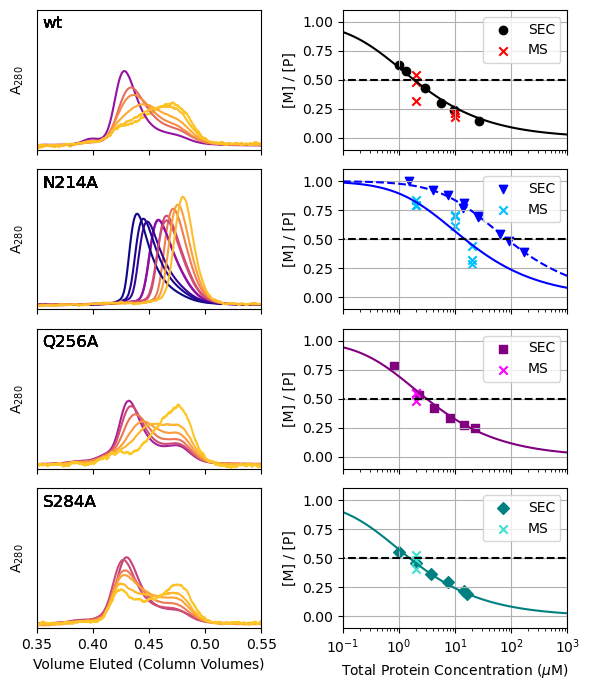

In [67]:
source_data_writer = pd.ExcelWriter('SEC_source_data.xlsx')
fit_data_writer = pd.ExcelWriter('SEC_fit_data.xlsx')
        
p_x = np.logspace(-1, 3, 100) # range to plot fits

# -------------------------

fig, axes = plt.subplots(4, 2, figsize=(6,7))

print('    \t     analytical SEC    \t\t     native mass spec')
print('    \t------------------------\t--------------------------')
print('mut\tKd (uM)\tsigK\t 95% CI\t\tKd (uM)\tsigK\t 95% CI')
print('---\t-------\t----\t-------\t\t-------\t----\t-------')

axR_legend = []

for im,m in enumerate(mutants):

    axL = axes[im,0]
    axR = axes[im,1]
    axR.grid()
    
    offset = -im * 0.0024
    
    data = all_data[m]
    
    n_concs = data.shape[1] - 1
    colors = plt.cm.plasma(np.logspace(-0.04,-3.0,41000))
    
    CV = data[:,0] / 24.0
    
    # define the region to integrate 
    start = np.argmin(np.abs(CV - low_cv_cutoff))
    end   = np.argmin(np.abs(CV - hgh_cv_cutoff))
    
    cs = []
    rs = []
    source_data = {}
    fit_data = {}
    
    for i in range(1, n_concs+1):

        UV = (data[:,i] - np.median(data[:,i]))

        auc = UV[start:end].sum()
        con = auc_to_concentration(auc)
        
        axL.plot(CV, UV / auc, color=colors[round(auc)])
        axL.text(0.355, 0.0026, m, fontsize=12, fontweight=10)
        
        if m == 'N214A':
            r = np.average(CV[start:end], weights=UV[start:end])
            
        else:
            params, _ = fit_double_gaussian(CV[start:end], UV[start:end])
            r = ratio_area_under_gaussians(params)
            
        cs.append(con)
        rs.append(r)
        source_data.update(
            {
                f"{con:.1f} µM volume (CV)": CV,
                f"{con:.1f} µM A280": UV / auc + offset,
            }
        )
        
    if m == 'N214A':
        rs = np.array(rs)
        
        r_min = 0.428
        r_max = rs.max()
        
        rs -= r_min
        rs /= r_max - r_min
        
    p = axR.scatter(cs, rs, color=mutant_colors[im], marker=mutant_markers[im])
    fit_data.update(
        {
            f"{m} concentration (µM)": cs,
            f"{m} monomer/total": rs,
        }
    )
    
    # fit to model
    K, sig_K = fit_K(cs, rs)
    if m == "N214A":
        axR.plot(p_x, r_p(p_x, K), "--", color=mutant_colors[im], label="_nolegend_")
    else:
        axR.plot(p_x, r_p(p_x, K), color=mutant_colors[im], label="_nolegend_")
    
    # estimate 95% CI -- though unlikely parameters are Gaussian
    interval = stats.t.interval(confidence=0.95, df=len(cs)-1, loc=K, scale=sig_K)
    
    axR_legend.append(p)

    source_data = {k: source_data[k] for k in natsorted(source_data, reverse=True)}
    df = pd.DataFrame.from_dict(source_data)
    df.to_excel(source_data_writer, sheet_name=m, index=False)

    df2 = pd.DataFrame.from_dict(fit_data)
    df2.to_excel(fit_data_writer, sheet_name=m, index=False)

    # --- mass spec data ---

    mutant_specific_ms_data = ms_data[ms_data["mutant"] == m.upper()]
    ms_concentrations = mutant_specific_ms_data["[P] (µM)"]
    ms_ratios = mutant_specific_ms_data["R (frac mono)"]
    #ms_ratios = mutant_specific_ms_data["monomer intensity"]/(2*mutant_specific_ms_data["dimer intensity"] + mutant_specific_ms_data["monomer intensity"])

    # fit to model
    K_ms, sig_K_ms = fit_K(ms_concentrations, ms_ratios)
    if m == "N214A":
        axR.plot(p_x, r_p(p_x, K_ms), color=mutant_colors[im], label="_nolegend_")

    axR.scatter(
        ms_concentrations,
        ms_ratios,
        marker="x",
        color=mass_spec_mutant_colors[im],
    )
    
    # estimate 95% CI -- though unlikely parameters are Gaussian
    interval_ms = stats.t.interval(
        confidence=0.95,
        df=len(ms_concentrations)-1,
        loc=K_ms,
        scale=sig_K_ms
    )
        
    fmt_tuple = (m, K, sig_K, interval[1] - K, K_ms, sig_K_ms, interval_ms[1] - K_ms)
    print('%s\t%.2f\t%.2f\t+/- %.2f\t%.2f\t%.2f\t+/- %.2f' % fmt_tuple)

    # --- formatting

    axL.set_xlim([0.35, 0.55])
    axL.set_ylim([-0.0001, 0.003])
    axL.set_yticks([])
    axL.set_ylabel('A$_{280}$')

    axR.set_xlim([1e-1, 1e3])
    axR.set_ylim([-0.1, 1.1])
    axR.set_xscale('log')
    axR.set_ylabel('[M] / [P]')
    axR.hlines(0.5, .5e-1, 2e3, 'k', linestyles='dashed')

    if im != 3:
        axL.get_xaxis().set_ticklabels([])
        axR.get_xaxis().set_ticklabels([])

    axR.legend(["SEC", "MS"], loc=1)
    
axL.set_xlabel('Volume Eluted (Column Volumes)')
axR.set_xlabel('Total Protein Concentration ($\mu$M)')

fig.subplots_adjust(hspace=0.0)

source_data_writer.close()
fit_data_writer.close()

plt.tight_layout()
plt.savefig('analytical_sec.pdf')
plt.show()

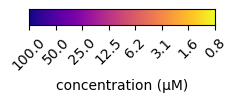

In [14]:
colorbar_concentrations = [100.0, 50.0, 25.0, 12.5, 6.2, 3.1, 1.6, 0.8]

plt.figure(figsize=(2.4,.2))
ax = plt.subplot(111)
gradient = np.vstack((np.linspace(0, 1, 256), np.linspace(0, 1, 256)))
ax.imshow(gradient, aspect='auto', cmap=plt.cm.plasma)
ax.set_yticks([])
plt.xticks(
    np.linspace(-1, 256, len(colorbar_concentrations)),
    ["%.1f" % c for c in sorted(colorbar_concentrations)][::-1],
    rotation=45
)
ax.set_xlabel('concentration (µM)')
plt.savefig('concentration_scale.pdf', bbox_inches='tight')
plt.show()

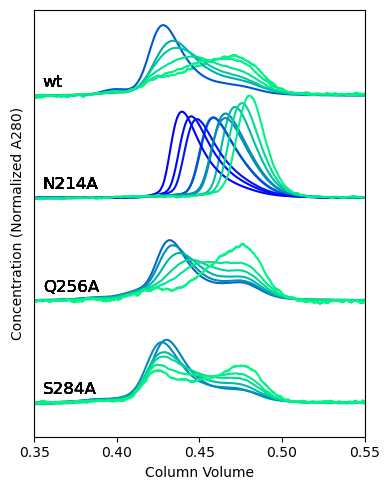

In [41]:
## JUST THE LEFT PANEL

p_x = np.logspace(-1, 3, 100) # range to plot fits

# smaller
#plt.figure(figsize=(3.5,4))

# larger
plt.figure(figsize=(4,5))

axL = plt.subplot(111)

for im,m in enumerate(mutants):
    
    offset = -im * 0.0024
    
    data = all_data[m]
    
    n_concs = data.shape[1] - 1
    colors = plt.cm.winter(np.logspace(0,-3,41000))
    
    CV = data[:,0] / 24.0
    
    # define the region to integrate 
    start = np.argmin(np.abs(CV - low_cv_cutoff))
    end   = np.argmin(np.abs(CV - hgh_cv_cutoff))
    
    cs = []
    rs = []
    
    for i in range(1, n_concs+1):

        UV = (data[:,i] - np.median(data[:,i]))

        auc = UV[start:end].sum()
        con = auc_to_concentration(auc)
        
        axL.plot(CV, UV / auc + offset, color=colors[round(auc)])
        axL.text(0.355, 2e-4 + offset, m, fontsize=12, fontweight=10)
        
        if m == 'N214A':
            #peak_idx = np.argmax(UV[start:end])
            #r = CV[start:end][peak_idx]
            r = np.average(CV[start:end], weights=UV[start:end])
            
        else:
            params, _ = fit_double_gaussian(CV[start:end], UV[start:end])
            r = ratio_area_under_gaussians(params)
            
        cs.append(con)
        rs.append(r)
        
    if m == 'N214A':
        rs = np.array(rs)
        
        r_min = 0.428
        r_max = rs.max()
        
        rs -= r_min
        rs /= r_max - r_min
    
        
        
axL.set_xlim([0.35, 0.55])
axL.set_ylim([-0.008, 0.002])
axL.set_yticks([])

axL.set_xlabel('Column Volume')
axL.set_ylabel('Concentration (Normalized A280)')

#plt.vlines([p1, p2], 0.0, 3.0, 'k', linestyles='dashed')
#plt.legend(['{} $\mu$M'.format(c) for c in concs], loc=1, title='')

plt.tight_layout()
plt.savefig('analytical_sec_one_panel.pdf')
#plt.savefig('analytical_sec_one_panel_small.pdf')
plt.show()

(array([5.27737595, 0.43190703, 0.01      , 1.26428421, 0.47267837,
       0.01      ]), 1)


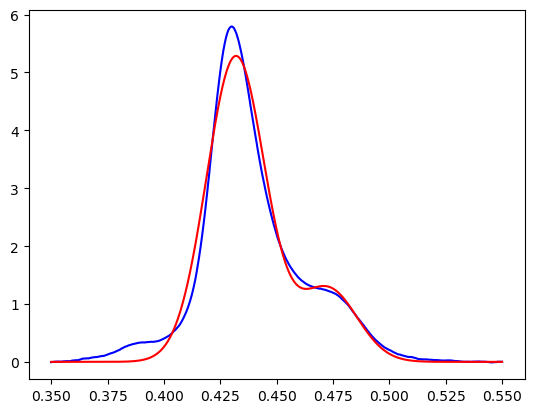

(array([4.43318297, 0.42925155, 0.01      , 1.23603784, 0.46970155,
       0.01      ]), 1)


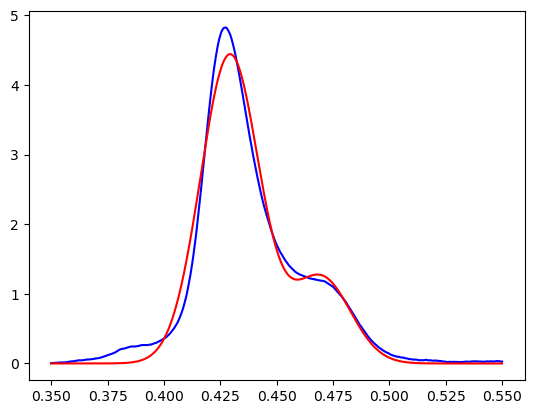

(array([2.1091724 , 0.43100501, 0.01      , 0.8845852 , 0.46961782,
       0.01      ]), 1)


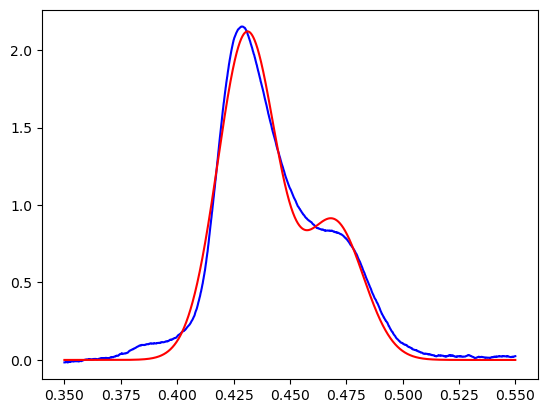

(array([0.96843408, 0.43168432, 0.01      , 0.56651285, 0.46980279,
       0.01      ]), 1)


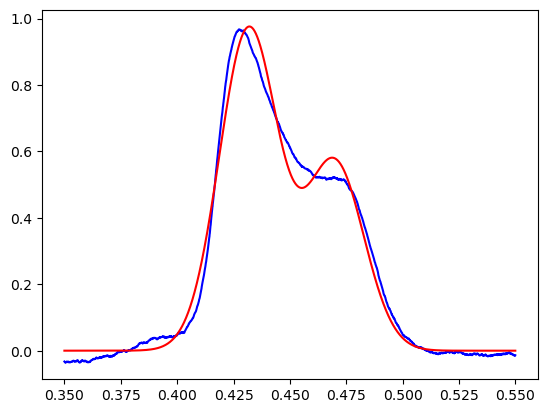

(array([0.43308119, 0.43034621, 0.01      , 0.36661674, 0.47010452,
       0.01      ]), 1)


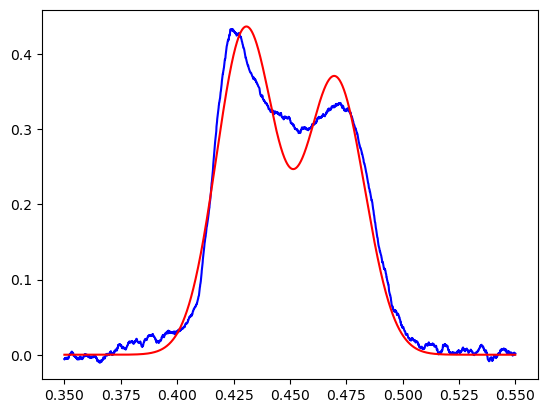

(array([0.1742709 , 0.42971407, 0.01      , 0.21722868, 0.47314442,
       0.01      ]), 1)


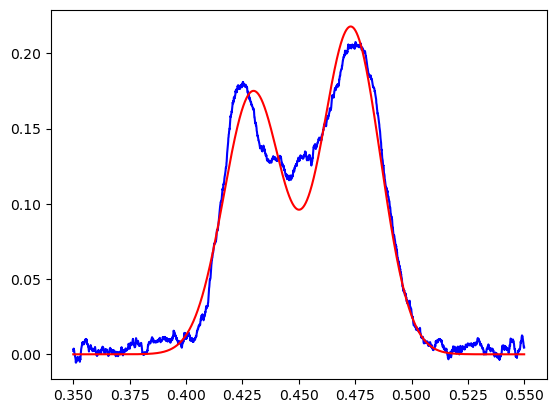

IndexError: index 7 is out of bounds for axis 1 with size 7

In [16]:
# just double check 2-gaussian fits are working well

check_data = all_data["S284A"]
CV_check = check_data[:,0] / 24.0

for ii in range(1,10):

    x = CV_check[start:end]
    y = check_data[start:end,ii] - np.median(check_data[:,ii])

    fit = fit_double_gaussian(x, y)
    print(fit)

    plt.figure()
    plt.plot( x, y, c='b' )
    plt.plot( x, double_gaussian(x, fit[0]), c='r' )
    plt.show()